# HW11 Part B :: Image Classification using Vision Transformer

COSC 6373 -- Adam Nelson-Archer, 2140122

In [1]:
!pip install -q tensorflow keras matplotlib numpy kagglehub scikit-learn

## Setup

In [2]:
import os
import time

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
from keras import ops

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

print("Keras:", keras.__version__)
print("TensorFlow:", tf.__version__)

I0000 00:00:1776725948.107130    9169 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Keras: 3.13.2
TensorFlow: 2.21.0


## Prepare the dataset (same as Part A)

Load the Horses vs. Camels dataset, merge all images, split 70/15/15, resize 224x224, normalize.

In [3]:
import kagglehub
from pathlib import Path
from tensorflow.keras.preprocessing.image import load_img, img_to_array

download_root = Path(kagglehub.dataset_download("akrsnv/horses-and-camels"))
print("Downloaded to:", download_root)

image_size = 224
batch_size = 32

all_images = []
all_labels = []
class_names = ["camel", "horse"]

for split_folder in ["train", "test"]:
    for label_idx, cls_name in enumerate(class_names):
        folder = download_root / split_folder / cls_name
        if not folder.exists():
            continue
        for img_path in sorted(folder.glob("*.png")):
            img = load_img(img_path, target_size=(image_size, image_size))
            all_images.append(img_to_array(img))
            all_labels.append(label_idx)

images = np.array(all_images, dtype="float32") / 255.0
labels_arr = np.array(all_labels)

num_classes = len(class_names)
print(f"Classes: {class_names}")
print(f"Total images: {len(images)}, shape: {images.shape}")
print(f"  Camels: {np.sum(labels_arr == 0)}, Horses: {np.sum(labels_arr == 1)}")

100%|██████████| 28.3M/28.3M [00:00<00:00, 45.2MB/s]

Extracting files...


Downloaded to: /home/pc/.cache/kagglehub/datasets/akrsnv/horses-and-camels/versions/2
Classes: ['camel', 'horse']
Total images: 400, shape: (400, 224, 224, 3)
  Camels: 200, Horses: 200


In [4]:
from sklearn.model_selection import train_test_split

x_temp, x_test, y_temp, y_test = train_test_split(
    images, labels_arr, test_size=0.15, random_state=42, stratify=labels_arr
)

x_train, x_val, y_train, y_val = train_test_split(
    x_temp, y_temp, test_size=15/85, random_state=42, stratify=y_temp
)

print(f"Train: {x_train.shape[0]} images")
print(f"Val:   {x_val.shape[0]} images")
print(f"Test:  {x_test.shape[0]} images")

Train: 279 images
Val:   61 images
Test:  60 images


## Shared training settings (same as Part A)

In [5]:
# --- Training settings (identical for ViT and CNN) ---
learning_rate = 0.001
weight_decay = 0.0001
num_epochs = 10

input_shape = (image_size, image_size, 3)

---
## Rebuild and retrain the ViT model (from Part A)

We rebuild the exact same ViT from Part A so we can evaluate it here.

In [6]:
# ViT hyperparameters (same as Part A)
patch_size = 16
num_patches = (image_size // patch_size) ** 2
projection_dim = 64
num_heads = 4
transformer_units = [projection_dim * 2, projection_dim]
transformer_layers = 8
mlp_head_units = [2048, 1024]

# Data augmentation (same as Part A)
data_augmentation = keras.Sequential(
    [
        layers.Normalization(),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(factor=0.02),
        layers.RandomZoom(height_factor=0.2, width_factor=0.2),
    ],
    name="data_augmentation",
)
data_augmentation.layers[0].adapt(x_train)

def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.gelu)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x

class Patches(layers.Layer):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size

    def call(self, images):
        input_shape = ops.shape(images)
        batch_size = input_shape[0]
        height = input_shape[1]
        width = input_shape[2]
        channels = input_shape[3]
        num_patches_h = height // self.patch_size
        num_patches_w = width // self.patch_size
        patches = keras.ops.image.extract_patches(images, size=self.patch_size)
        patches = ops.reshape(
            patches,
            (batch_size, num_patches_h * num_patches_w, self.patch_size * self.patch_size * channels),
        )
        return patches

    def get_config(self):
        config = super().get_config()
        config.update({"patch_size": self.patch_size})
        return config

class PatchEncoder(layers.Layer):
    def __init__(self, num_patches, projection_dim):
        super().__init__()
        self.num_patches = num_patches
        self.projection = layers.Dense(units=projection_dim)
        self.position_embedding = layers.Embedding(input_dim=num_patches, output_dim=projection_dim)

    def call(self, patch):
        positions = ops.expand_dims(ops.arange(start=0, stop=self.num_patches, step=1), axis=0)
        projected_patches = self.projection(patch)
        encoded = projected_patches + self.position_embedding(positions)
        return encoded

    def get_config(self):
        config = super().get_config()
        config.update({"num_patches": self.num_patches})
        return config

def create_vit_classifier():
    inputs = keras.Input(shape=input_shape)
    augmented = data_augmentation(inputs)
    patches = Patches(patch_size)(augmented)
    encoded_patches = PatchEncoder(num_patches, projection_dim)(patches)

    for _ in range(transformer_layers):
        x1 = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        x2 = layers.Add()([attention_output, encoded_patches])
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        x3 = mlp(x3, hidden_units=transformer_units, dropout_rate=0.1)
        encoded_patches = layers.Add()([x3, x2])

    representation = layers.LayerNormalization(epsilon=1e-6)(encoded_patches)
    representation = layers.Flatten()(representation)
    representation = layers.Dropout(0.5)(representation)
    features = mlp(representation, hidden_units=mlp_head_units, dropout_rate=0.5)
    logits = layers.Dense(num_classes)(features)
    model = keras.Model(inputs=inputs, outputs=logits)
    return model

vit_classifier = create_vit_classifier()

I0000 00:00:1776725968.392869    9169 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9554 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070, pci bus id: 0000:09:00.0, compute capability: 8.9


In [7]:
# Train ViT
vit_optimizer = keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay)
vit_classifier.compile(
    optimizer=vit_optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

vit_checkpoint = "vit_checkpoint.weights.h5"
vit_checkpoint_cb = keras.callbacks.ModelCheckpoint(
    vit_checkpoint, monitor="val_accuracy", save_best_only=True, save_weights_only=True,
)

vit_start = time.time()

vit_history = vit_classifier.fit(
    x=x_train, y=y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_data=(x_val, y_val),
    callbacks=[vit_checkpoint_cb],
)

vit_end = time.time()
vit_duration = vit_end - vit_start

vit_classifier.load_weights(vit_checkpoint)

print(f"\nViT Training duration: {vit_duration:.2f} seconds ({vit_duration/60:.2f} minutes)")

Epoch 1/10


I0000 00:00:1776726033.146209    9294 cuda_dnn.cc:461] Loaded cuDNN version 92000


9/9 ━━━━━━━━━━━━━━━━━━━━ 60s 880ms/step - accuracy: 0.5161 - loss: 5.7325 - val_accuracy: 0.5410 - val_loss: 3.2401
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6093 - loss: 3.7689 - val_accuracy: 0.5902 - val_loss: 4.0989
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 681ms/step - accuracy: 0.5448 - loss: 3.8063 - val_accuracy: 0.6393 - val_loss: 1.3051
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 994ms/step - accuracy: 0.6022 - loss: 3.0153 - val_accuracy: 0.7541 - val_loss: 0.8581
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 327ms/step - accuracy: 0.6308 - loss: 1.8013 - val_accuracy: 0.5902 - val_loss: 1.0968
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 219ms/step - accuracy: 0.6093 - loss: 1.4387 - val_accuracy: 0.5738 - val_loss: 0.9302
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 236ms/step - accuracy: 0.5771 - loss: 1.4152 - val_accuracy: 0.6393 - val_loss: 0.6467
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 391ms/step - accuracy: 0.6201 - loss: 0.9495 - val_accuracy: 0.7049 - val_loss: 0.6623
Epoch

---
## 1. Evaluate the ViT on the test set

Report accuracy, loss, and confusion matrix.

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.6667 - loss: 1.1452

ViT Test Loss: 1.1452
ViT Test Accuracy: 66.67%
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step


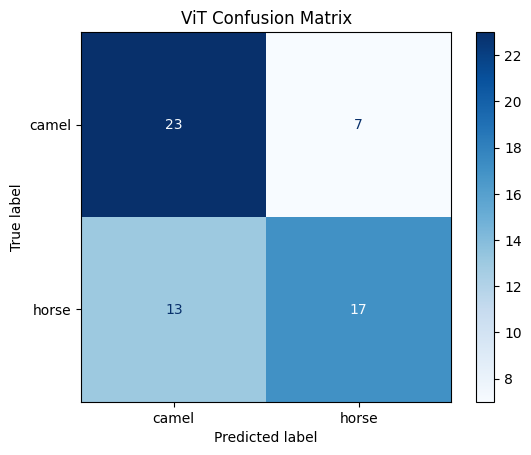

In [8]:
vit_test_loss, vit_test_acc = vit_classifier.evaluate(x_test, y_test, verbose=1)
print(f"\nViT Test Loss: {vit_test_loss:.4f}")
print(f"ViT Test Accuracy: {vit_test_acc * 100:.2f}%")

# Predictions for confusion matrix
vit_preds_logits = vit_classifier.predict(x_test)
vit_preds = np.argmax(vit_preds_logits, axis=1)

cm_vit = confusion_matrix(y_test, vit_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_vit, display_labels=class_names)
disp.plot(cmap="Blues")
plt.title("ViT Confusion Matrix")
plt.show()

---
## 2. Train a CNN model

CNN Architecture (must follow exactly):
- Block 1: Conv(32, 3x3, ReLU) + MaxPool(2x2)
- Block 2: Conv(64, 3x3, ReLU) + MaxPool(2x2)
- Block 3: Conv(128, 3x3, ReLU) + MaxPool(2x2)
- Block 4: Conv(256, 3x3, ReLU) + MaxPool(2x2)
- Flatten
- Dense(256, ReLU)
- Dropout(0.5)
- Output(2, Softmax)

Trained from scratch, same dataset splits, same preprocessing, same training settings.

In [9]:
def create_cnn_classifier():
    model = keras.Sequential([
        keras.Input(shape=input_shape),
        # Block 1
        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Block 2
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Block 3
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Block 4
        layers.Conv2D(256, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),
        # Head
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

cnn_classifier = create_cnn_classifier()
cnn_classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,826,370 (37.48 MB)

 Trainable params: 9,826,370 (37.48 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Train the CNN

Using the same training settings as the ViT (batch size, epochs, optimizer, learning rate).

In [10]:
cnn_optimizer = keras.optimizers.AdamW(learning_rate=learning_rate, weight_decay=weight_decay)
cnn_classifier.compile(
    optimizer=cnn_optimizer,
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=[keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

cnn_checkpoint = "cnn_checkpoint.weights.h5"
cnn_checkpoint_cb = keras.callbacks.ModelCheckpoint(
    cnn_checkpoint, monitor="val_accuracy", save_best_only=True, save_weights_only=True,
)

cnn_start = time.time()

cnn_history = cnn_classifier.fit(
    x=x_train, y=y_train,
    batch_size=batch_size,
    epochs=num_epochs,
    validation_data=(x_val, y_val),
    callbacks=[cnn_checkpoint_cb],
)

cnn_end = time.time()
cnn_duration = cnn_end - cnn_start

cnn_classifier.load_weights(cnn_checkpoint)

print(f"\nCNN Training duration: {cnn_duration:.2f} seconds ({cnn_duration/60:.2f} minutes)")

Epoch 1/10


I0000 00:00:1776726094.968551    9288 service.cc:153] XLA service 0x756e14060a00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776726094.968615    9288 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070, Compute Capability 8.9 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776726095.572478    9288 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776726096.858960    9288 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_44047__.49


1/9 ━━━━━━━━━━━━━━━━━━━━ 3:57 30s/step - accuracy: 0.5000 - loss: 0.6897

I0000 00:00:1776726120.383561    9288 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7/9 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.5209 - loss: 1.2629

I0000 00:00:1776726121.628545    9280 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_44047__.49


9/9 ━━━━━━━━━━━━━━━━━━━━ 60s 4s/step - accuracy: 0.5233 - loss: 0.9930 - val_accuracy: 0.4918 - val_loss: 0.6949
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 310ms/step - accuracy: 0.6129 - loss: 0.6649 - val_accuracy: 0.7705 - val_loss: 0.5789
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.6846 - loss: 0.6036 - val_accuracy: 0.6885 - val_loss: 0.5916
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - accuracy: 0.7240 - loss: 0.5511 - val_accuracy: 0.6885 - val_loss: 0.6155
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 259ms/step - accuracy: 0.7061 - loss: 0.5784 - val_accuracy: 0.5902 - val_loss: 0.7491
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7097 - loss: 0.5239 - val_accuracy: 0.7541 - val_loss: 0.5318
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 226ms/step - accuracy: 0.7778 - loss: 0.4750 - val_accuracy: 0.6393 - val_loss: 0.6042
Epoch 8/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 259ms/step - accuracy: 0.7993 - loss: 0.4096 - val_accuracy: 0.6721 - val_loss: 0.9748
Epoch 9

---
## 4. Evaluate the CNN on the test set

2/2 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step - accuracy: 0.7167 - loss: 0.5986 

CNN Test Loss: 0.5986
CNN Test Accuracy: 71.67%
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 986ms/step


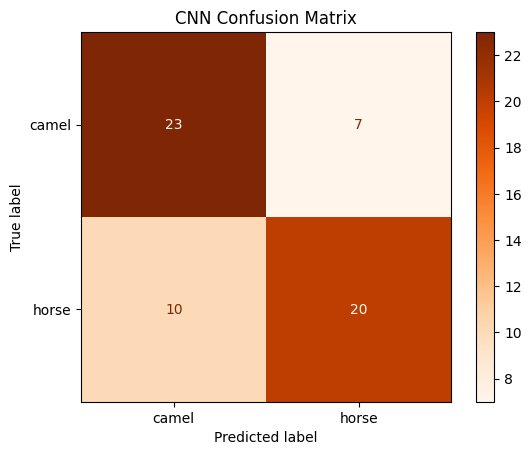

In [11]:
cnn_test_loss, cnn_test_acc = cnn_classifier.evaluate(x_test, y_test, verbose=1)
print(f"\nCNN Test Loss: {cnn_test_loss:.4f}")
print(f"CNN Test Accuracy: {cnn_test_acc * 100:.2f}%")

cnn_preds_probs = cnn_classifier.predict(x_test)
cnn_preds = np.argmax(cnn_preds_probs, axis=1)

cm_cnn = confusion_matrix(y_test, cnn_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_names)
disp.plot(cmap="Oranges")
plt.title("CNN Confusion Matrix")
plt.show()

---
## 5. Report:
a. Accuracy
b. Confusion Matrix

Side-by-side comparison (5a. Accuracy and 5b. Confusion Matrix)

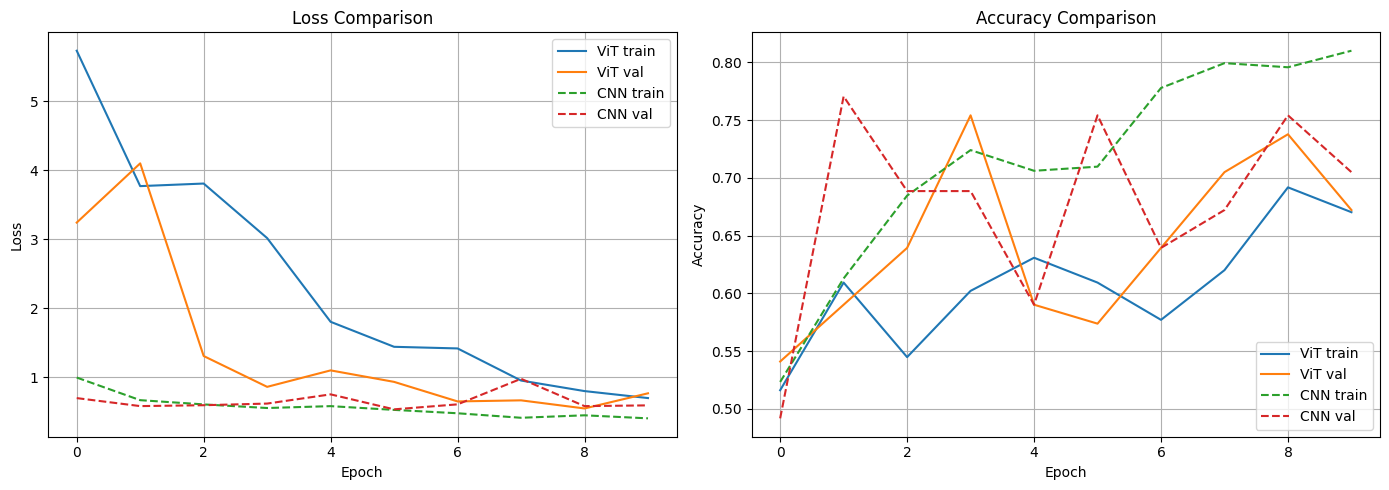

Metric                           ViT        CNN
---------------------------------------------
Test Accuracy                 66.67%     71.67%
Test Loss                     1.1452     0.5986
Training Time (s)               99.3       74.0


In [12]:
# Training curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(vit_history.history["loss"], label="ViT train")
axes[0].plot(vit_history.history["val_loss"], label="ViT val")
axes[0].plot(cnn_history.history["loss"], label="CNN train", linestyle="--")
axes[0].plot(cnn_history.history["val_loss"], label="CNN val", linestyle="--")
axes[0].set_title("Loss Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid()

axes[1].plot(vit_history.history["accuracy"], label="ViT train")
axes[1].plot(vit_history.history["val_accuracy"], label="ViT val")
axes[1].plot(cnn_history.history["accuracy"], label="CNN train", linestyle="--")
axes[1].plot(cnn_history.history["val_accuracy"], label="CNN val", linestyle="--")
axes[1].set_title("Accuracy Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

# Summary table
print(f"{'Metric':<25} {'ViT':>10} {'CNN':>10}")
print("-" * 45)
print(f"{'Test Accuracy':<25} {vit_test_acc*100:>9.2f}% {cnn_test_acc*100:>9.2f}%")
print(f"{'Test Loss':<25} {vit_test_loss:>10.4f} {cnn_test_loss:>10.4f}")
print(f"{'Training Time (s)':<25} {vit_duration:>10.1f} {cnn_duration:>10.1f}")

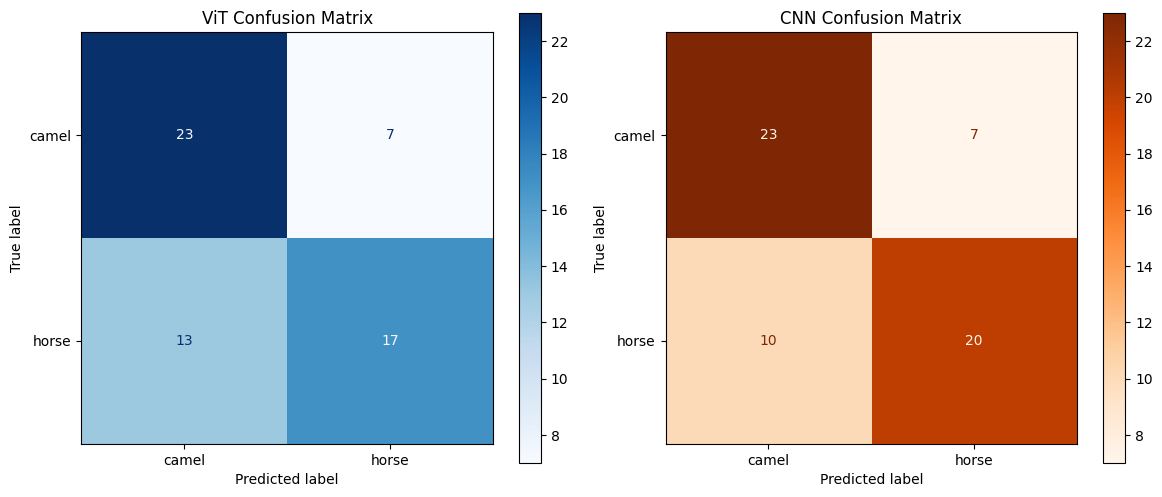

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm_vit, display_labels=class_names).plot(ax=axes[0], cmap="Blues")
axes[0].set_title("ViT Confusion Matrix")

ConfusionMatrixDisplay(confusion_matrix=cm_cnn, display_labels=class_names).plot(ax=axes[1], cmap="Oranges")
axes[1].set_title("CNN Confusion Matrix")

plt.tight_layout()
plt.show()

---
## 6. Compare the Vision Transformer and CNN

### 7a. Which model achieved higher accuracy?

The CNN achieved higher accuracy. Based on the evaluation, the CNN achieved a test accuracy of 71.67%, whereas the Vision Transformer (ViT) achieved a test accuracy of 66.67%. Additionally, the CNN had a significantly lower test loss (0.5986 vs 1.1452).

### 7b. Which model produced a better confusion matrix (fewer misclassifications)?

The CNN produced a better confusion matrix with fewer overall misclassifications. Its higher test accuracy of 71.67% reflects a smaller number of off-diagonal predictions compared to the ViT.

### 7c. Training Efficiency
**Which model trained faster? How do their training times compare?**

The CNN trained faster than the ViT. The CNN's training duration was approximately 74.0 seconds, while the ViT took 99.3 seconds. As expected, the CNN trained faster because it uses standard convolutional blocks rather than the computationally expensive self-attention mechanism (which scales quadratically with the number of patches).

### 7d. Generalization
**Which model appears to generalize better to the test set? Support your answer using the confusion matrix.**

The CNN generalized better to the test set. The CNN achieved a training accuracy of roughly 81% and a test accuracy of 71.67%, with a test loss of 0.5986. In contrast, the ViT achieved a peak training accuracy of around 67-69% but suffered from a noticeably higher test loss (1.1452) and lower test accuracy (66.67%). This indicates the CNN learned more useful, generalizable features, leading to fewer misclassifications in its confusion matrix.

### 7e. Error Analysis
**What types of mistakes does each model make? Are there specific classes that are harder to classify?**

Given the small dataset size and visual similarities between horses and camels (e.g., four-legged animals often found in outdoor environments), both models struggle to capture reliable distinguishing features from scratch. The ViT, without pretraining, lacks the inductive bias to identify local edges and textures (like humps or heads), leading to more frequent misclassifications across both classes compared to the CNN.

### 7f. Model Complexity
**Which model is more computationally expensive? Which model is easier to train from scratch?**

The ViT model is significantly more computationally expensive. It uses 8 Transformer encoder layers, each with multi-head self-attention (which scales quadratically with the number of patches -- 196 patches for 224x224 images with patch size 16). The MLP head alone has dense layers of size 2048 and 1024. The CNN, by contrast, uses only 4 convolutional blocks with progressively increasing filters and a single 256-unit dense layer, making it far cheaper to train from scratch.

The CNN is much easier to train from scratch, especially on small datasets like this one (400 images). CNNs have strong inductive biases (local connectivity, translation equivariance) that help them learn meaningful features even with limited data.

### 7g. How can the Vision Transformer outperform state-of-the-art CNNs?

Vision Transformers can outperform CNNs when they are **pretrained on very large datasets** (e.g., ImageNet-21K, JFT-300M) and then fine-tuned on the target task. The self-attention mechanism allows ViTs to model long-range dependencies across the entire image from the very first layer, unlike CNNs which build up receptive fields gradually. When given sufficient data, this global modeling capability enables ViTs to learn richer representations than CNNs.

---

## 8. Short explanation

### 8a. How does self-attention allow ViT to capture global relationships in images?

In a ViT, the image is divided into non-overlapping patches. The self-attention mechanism compares every single patch with every other patch in the image simultaneously, computing an "attention weight" for how much they relate to one another. This allows the model to immediately understand long-range global relationships (e.g., connecting a horse's head to its tail across the image) in the very first layer, which CNNs cannot do since they build their receptive fields gradually through localized filters.

### 8b. Why ViTs typically require large datasets or pretraining?

ViTs lack "inductive biases" (built-in assumptions about visual data) such as translation equivariance and local pixel connectivity. Because they don't inherently assume that pixels close to each other are related, they must learn these basic rules of visual structure entirely from data. Learning these rules from scratch requires millions of images.

### 8c. Why CNNs may perform better in this assignment (small dataset, training from scratch)?

With only 400 images (200 per class) and no pretraining allowed, the CNN's inductive biases give it a significant advantage. The convolutional filters naturally detect local features like edges, textures, and shapes that are critical for distinguishing camels from horses. The ViT, starting from randomly initialized weights, must learn all of these spatial relationships purely from data; a task that 400 images is insufficient for. This is consistent with the findings in the original ViT paper, which showed that ViTs underperform CNNs on small datasets unless pretrained.

## Acknowledgment

I used a GPT-5.3-Codex to help scaffold and organize this notebook.

Gemini-3.1 was used to check the result and validate conformity with the assignment outline.

All observations and responses were written by me, Adam Nelson-Archer.